# Explore the charge-region dataset

This notebook opens the Bruker `.d` dataset and the exported long-format dominant-charge table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from opentimspy import OpenTIMS


In [2]:
project_root = Path.cwd().resolve()
if not (project_root / 'data').is_dir():
    project_root = project_root.parent

dataset_path = project_root / 'data' / 'G260811_092_Slot2-1_1_24990.d'
dominant_charges_path = project_root / 'dominant_charges_long_polar_global_min30_350_1200_10Da.csv'

assert dataset_path.is_dir(), dataset_path
assert dominant_charges_path.is_file(), dominant_charges_path
dataset_path, dominant_charges_path

(PosixPath('/mnt/bigssd/tickyticker/data/G260811_092_Slot2-1_1_24990.d'),
 PosixPath('/mnt/bigssd/tickyticker/dominant_charges_long_polar_global_min30_350_1200_10Da.csv'))

In [3]:
dataset = OpenTIMS(dataset_path)
print(f'MS1 frames: {len(dataset.ms1_frames)}')
print(f'Scan range: {dataset.min_scan}–{dataset.max_scan}')
print(f'm/z range: {dataset.min_mz:.3f}–{dataset.max_mz:.3f}')

MS1 frames: 890
Scan range: 0–917
m/z range: 99.994–1700.000


In [4]:
dominant_charges = pd.read_csv(dominant_charges_path)
dominant_charges.head()

,mz_bin,mobility_bin,mz,inv_ion_mobility,dominant_charge,intensity_weight
0,42,0,525.0,0.606084,3,313
1,37,1,475.0,0.616073,3,340
2,41,1,515.0,0.616073,3,271
3,12,2,225.0,0.626062,1,425
4,14,2,245.0,0.626062,3,1164


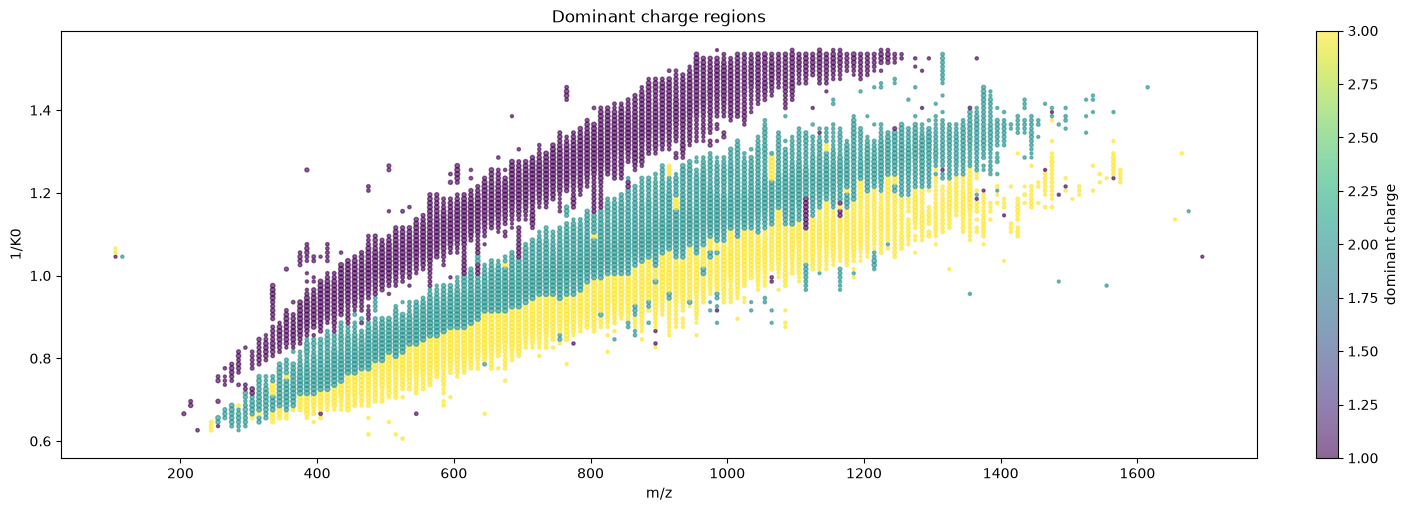

In [5]:
figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
scatter = axis.scatter(
    dominant_charges['mz'],
    dominant_charges['inv_ion_mobility'],
    c=dominant_charges['dominant_charge'],
    s=np.clip(np.log1p(dominant_charges['intensity_weight']), 1, 20),
    cmap='viridis',
    alpha=0.6,
)
axis.set(xlabel='m/z', ylabel='1/K0', title='Dominant charge regions')
figure.colorbar(scatter, ax=axis, label='dominant charge')
plt.show()

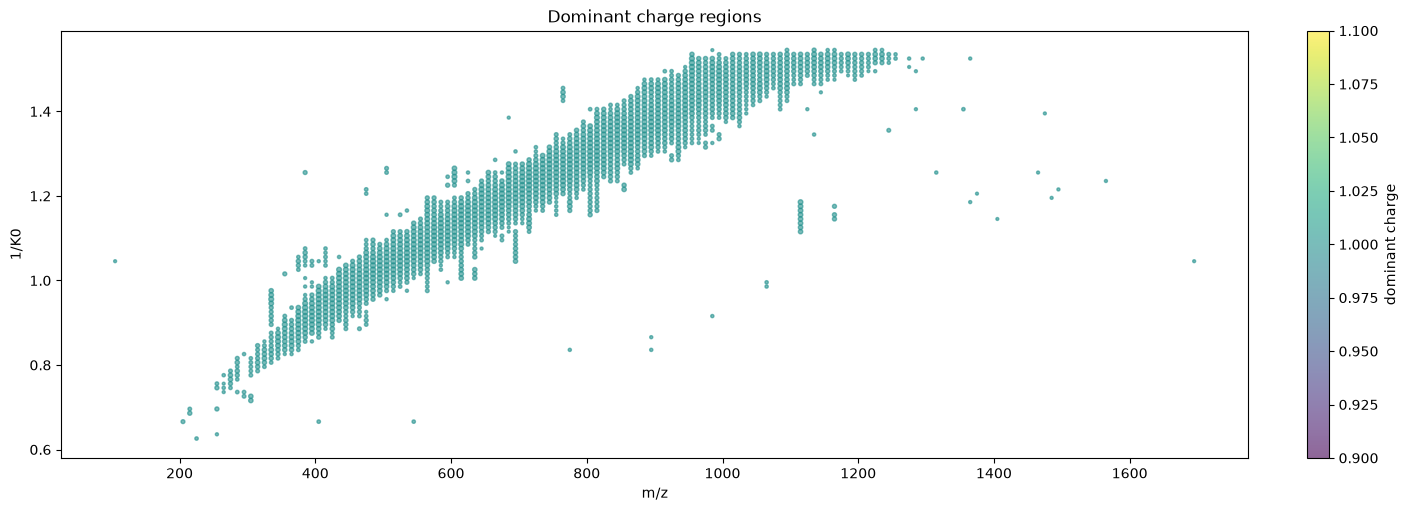

In [6]:
dominant_charges_1 = dominant_charges.query("dominant_charge == 1")

figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
scatter = axis.scatter(
    dominant_charges_1['mz'],
    dominant_charges_1['inv_ion_mobility'],
    c=dominant_charges_1['dominant_charge'],
    s=np.clip(np.log1p(dominant_charges_1['intensity_weight']), 1, 20),
    cmap='viridis',
    alpha=0.6,
)
axis.set(xlabel='m/z', ylabel='1/K0', title='Dominant charge regions')
figure.colorbar(scatter, ax=axis, label='dominant charge')
plt.show()

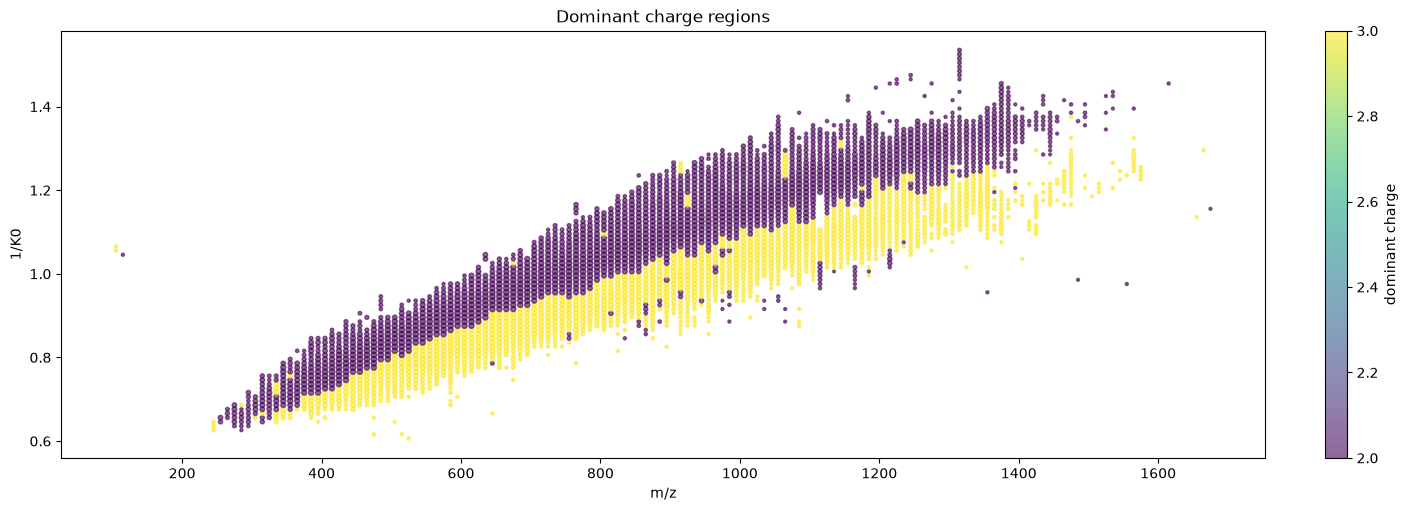

In [7]:
dominant_charges_23 = dominant_charges.query("dominant_charge != 1")

figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
scatter = axis.scatter(
    dominant_charges_23['mz'],
    dominant_charges_23['inv_ion_mobility'],
    c=dominant_charges_23['dominant_charge'],
    s=np.clip(np.log1p(dominant_charges_23['intensity_weight']), 1, 20),
    cmap='viridis',
    alpha=0.6,
)
axis.set(xlabel='m/z', ylabel='1/K0', title='Dominant charge regions')
figure.colorbar(scatter, ax=axis, label='dominant charge')
plt.show()

In [8]:
print(dominant_charges.mz_bin.max(), dominant_charges.mobility_bin.max())

159 94


## Robust 1+ and 2+ axes

The fit is intensity-weighted and uses Huber iteratively reweighted least squares.

In [9]:
def robust_line_fit(mz, inv_ion_mobility, weights, iterations=30):
    """Fit 1/K0 = intercept + slope × m/z with weighted Huber IRLS."""
    design = np.column_stack((np.ones(len(mz)), mz))
    current_weights = weights.astype(float).copy()
    coefficients = np.zeros(2)
    for _ in range(iterations):
        previous = coefficients.copy()
        sqrt_weights = np.sqrt(current_weights)
        coefficients = np.linalg.lstsq(
            design * sqrt_weights[:, None],
            inv_ion_mobility * sqrt_weights,
            rcond=None,
        )[0]
        residual = inv_ion_mobility - design @ coefficients
        scale = max(1.4826 * np.median(np.abs(residual - np.median(residual))), 1e-8)
        huber = np.minimum(1.0, 1.345 * scale / np.maximum(np.abs(residual), 1e-12))
        current_weights = weights * huber
        if np.max(np.abs(coefficients - previous)) < 1e-10:
            break
    return coefficients


In [10]:
border_mz_left, border_mz_right = 350.0, 1200.0
clouds = dominant_charges.loc[
    dominant_charges['dominant_charge'].isin([1, 2])
    & dominant_charges['mz'].between(border_mz_left, border_mz_right)
].copy()

line_1 = robust_line_fit(
    clouds.loc[clouds.dominant_charge == 1, 'mz'].to_numpy(),
    clouds.loc[clouds.dominant_charge == 1, 'inv_ion_mobility'].to_numpy(),
    clouds.loc[clouds.dominant_charge == 1, 'intensity_weight'].to_numpy(),
)
line_2 = robust_line_fit(
    clouds.loc[clouds.dominant_charge == 2, 'mz'].to_numpy(),
    clouds.loc[clouds.dominant_charge == 2, 'inv_ion_mobility'].to_numpy(),
    clouds.loc[clouds.dominant_charge == 2, 'intensity_weight'].to_numpy(),
)

if np.isclose(line_1[1], line_2[1]):
    raise RuntimeError('The two robust axes are parallel; their intersection is undefined.')
intersection_mz = (line_2[0] - line_1[0]) / (line_1[1] - line_2[1])
intersection_mobility = line_1[0] + line_1[1] * intersection_mz
pd.DataFrame(
    {'intercept': [line_1[0], line_2[0]], 'slope': [line_1[1], line_2[1]]},
    index=['dominant 1+', 'dominant 2+'],
), (intersection_mz, intersection_mobility)


(             intercept     slope
 dominant 1+   0.593156  0.000882
 dominant 2+   0.501546  0.000669,
 (np.float64(-430.78848814284777), np.float64(0.21331250076007274)))

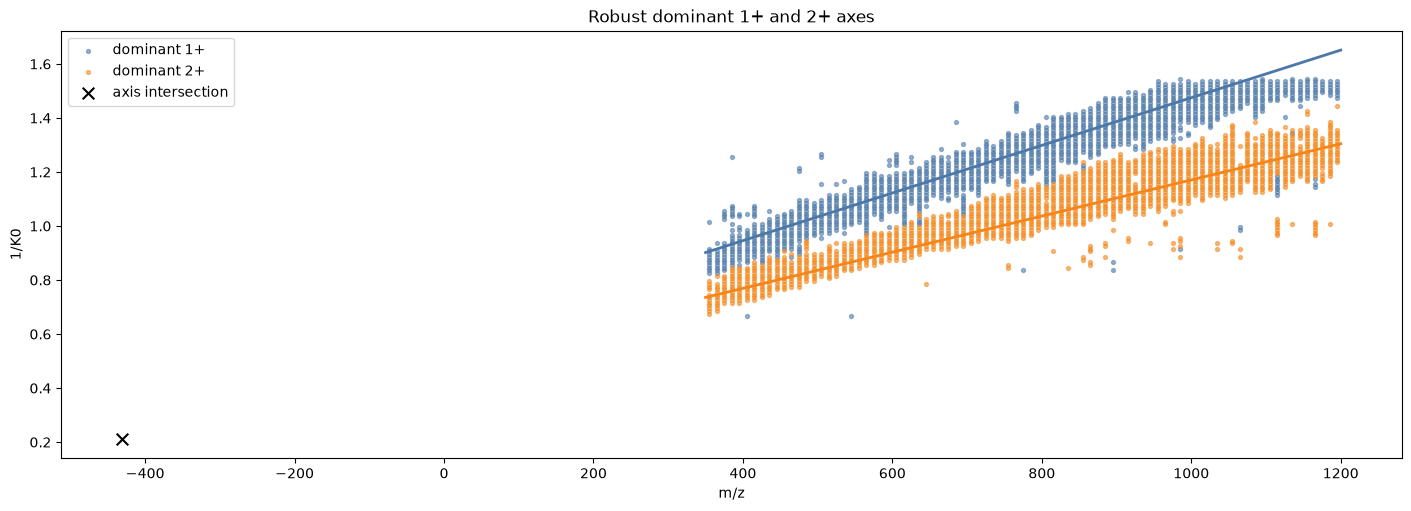

In [11]:
figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
for charge, colour in [(1, '#4c78a8'), (2, '#f58518')]:
    points = clouds.loc[clouds.dominant_charge == charge]
    axis.scatter(points.mz, points.inv_ion_mobility, s=8, color=colour, alpha=0.55, label=f'dominant {charge}+')
mz_line = np.array([border_mz_left, border_mz_right])
axis.plot(mz_line, line_1[0] + line_1[1] * mz_line, color='#4c78a8', linewidth=2)
axis.plot(mz_line, line_2[0] + line_2[1] * mz_line, color='#f58518', linewidth=2)
axis.scatter(intersection_mz, intersection_mobility, color='black', marker='x', s=70, label='axis intersection')
axis.set(xlabel='m/z', ylabel='1/K0', title='Robust dominant 1+ and 2+ axes')
axis.legend()
plt.show()


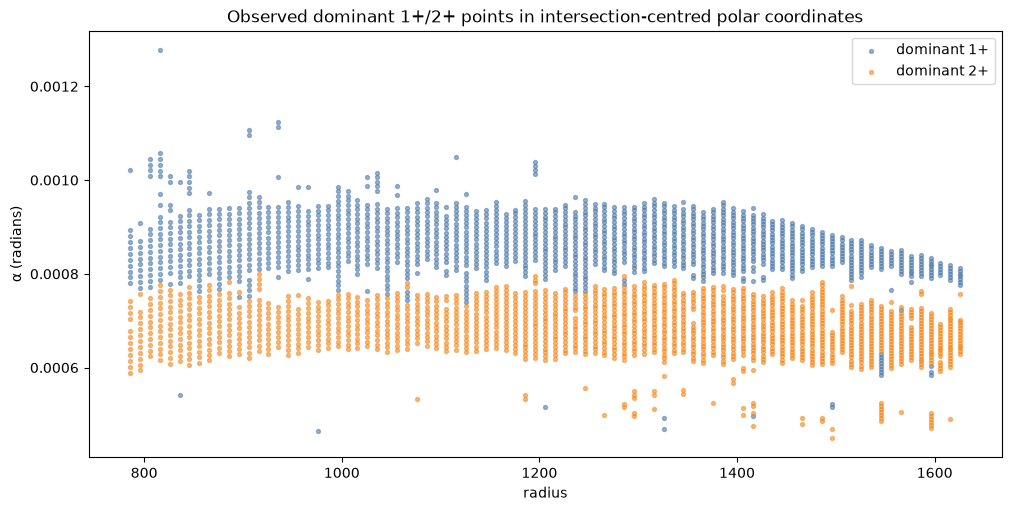

In [12]:
# Keep the original m/z and 1/K0 units: tan(alpha) is then the original-coordinate slope.
clouds['polar_radius'] = np.hypot(
    clouds.mz - intersection_mz,
    clouds.inv_ion_mobility - intersection_mobility,
)
clouds['alpha'] = np.arctan2(
    clouds.inv_ion_mobility - intersection_mobility,
    clouds.mz - intersection_mz,
)

figure, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
for charge, colour in [(1, '#4c78a8'), (2, '#f58518')]:
    points = clouds.loc[clouds.dominant_charge == charge]
    axis.scatter(points.polar_radius, points.alpha, s=8, color=colour, alpha=0.55, label=f'dominant {charge}+')
axis.set(xlabel='radius', ylabel='α (radians)', title='Observed dominant 1+/2+ points in intersection-centred polar coordinates')
axis.legend()
plt.show()


In [13]:
alpha_quantiles = clouds.groupby('dominant_charge')['alpha'].quantile([0.05, 0.95]).unstack()
alpha_quantiles.columns = ['alpha_5pct', 'alpha_95pct']
alpha_lower = max(alpha_quantiles.loc[1, 'alpha_5pct'], alpha_quantiles.loc[2, 'alpha_5pct'])
alpha_upper = min(alpha_quantiles.loc[1, 'alpha_95pct'], alpha_quantiles.loc[2, 'alpha_95pct'])
alpha_separator = (alpha_lower + alpha_upper) / 2.0
separator_slope = np.tan(alpha_separator)

print(f'Allowed alpha interval: [{alpha_lower:.8f}, {alpha_upper:.8f}] radians')
print(f'Separator alpha: {alpha_separator:.8f} radians')
print(f'Original-coordinate slope tan(alpha): {separator_slope:.10f}')
alpha_quantiles


Allowed alpha interval: [0.00078639, 0.00075978] radians
Separator alpha: 0.00077309 radians
Original-coordinate slope tan(alpha): 0.0007730852


,alpha_5pct,alpha_95pct
dominant_charge,,
1,0.000786,0.000951
2,0.000608,0.000760


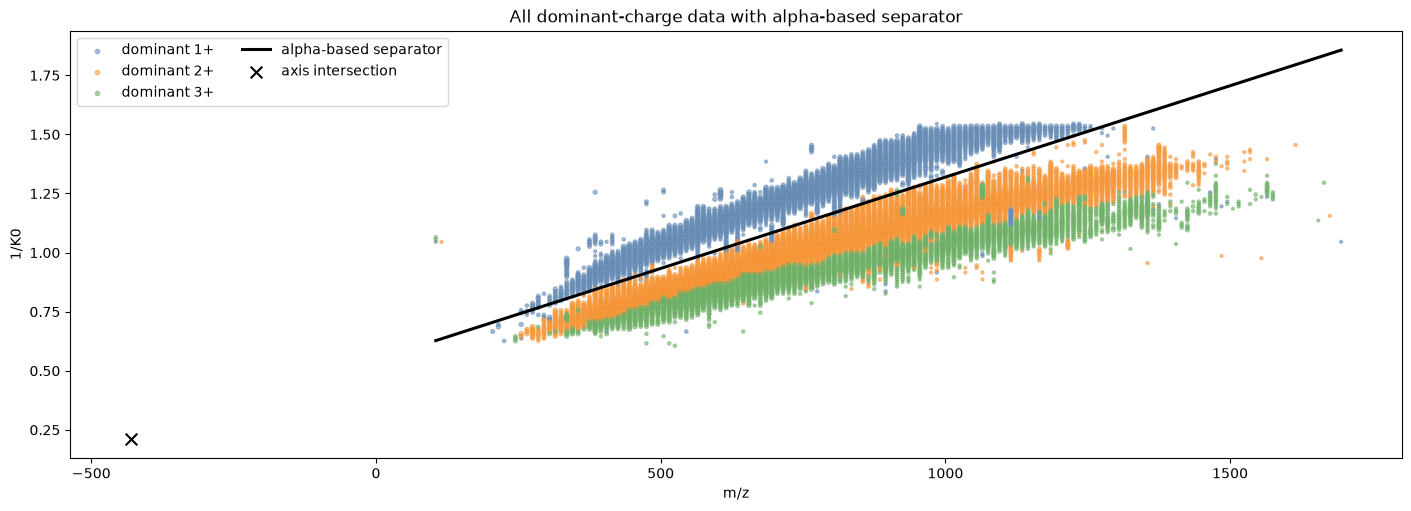

In [14]:
figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
colours = {1: '#4c78a8', 2: '#f58518', 3: '#54a24b'}
for charge, colour in colours.items():
    points = dominant_charges.loc[dominant_charges.dominant_charge == charge]
    axis.scatter(
        points.mz, points.inv_ion_mobility,
        s=np.clip(np.log1p(points.intensity_weight), 2, 18),
        color=colour, alpha=0.45, label=f'dominant {charge}+',
    )
mz_line = np.array([dominant_charges.mz.min(), dominant_charges.mz.max()])
separator_line = intersection_mobility + separator_slope * (mz_line - intersection_mz)
axis.plot(mz_line, separator_line, color='black', linewidth=2.2, label='alpha-based separator')
axis.scatter(intersection_mz, intersection_mobility, color='black', marker='x', s=70, label='axis intersection')
axis.set(xlabel='m/z', ylabel='1/K0', title='All dominant-charge data with alpha-based separator')
axis.legend(ncol=2)
plt.show()


## Two-segment robust continuation

Fit a robust line to each m/z half of the α-filtered dominant 1+/2+ points. The two lines are extended beyond the observed interval and meet at their fitted intersection.

In [15]:
# `clouds` is the last stable filtered table: dominant 1+/2+ boxes in the selected m/z interval.
# Splitting at the median keeps both robust fits populated; the two lines are extended past the split.
fit_points = clouds.copy()
split_mz = float(fit_points.mz.median())
left_points = fit_points.loc[fit_points.mz <= split_mz]
right_points = fit_points.loc[fit_points.mz > split_mz]
if len(left_points) < 3 or len(right_points) < 3:
    raise RuntimeError("Each m/z segment needs at least three filtered points.")

left_line = robust_line_fit(
    left_points.mz.to_numpy(),
    left_points.inv_ion_mobility.to_numpy(),
    left_points.intensity_weight.to_numpy(),
)
right_line = robust_line_fit(
    right_points.mz.to_numpy(),
    right_points.inv_ion_mobility.to_numpy(),
    right_points.intensity_weight.to_numpy(),
)
if np.isclose(left_line[1], right_line[1]):
    raise RuntimeError("The two segment lines are parallel; no intersection node exists.")
node_mz = (right_line[0] - left_line[0]) / (left_line[1] - right_line[1])
node_mobility = left_line[0] + left_line[1] * node_mz

pd.DataFrame(
    {"intercept": [left_line[0], right_line[0]], "slope": [left_line[1], right_line[1]]},
    index=["left filtered segment", "right filtered segment"],
), (node_mz, node_mobility)


(                        intercept     slope
 left filtered segment    0.466715  0.000794
 right filtered segment   0.801780  0.000398,
 (np.float64(845.6636030705513), np.float64(1.1385100532644377)))

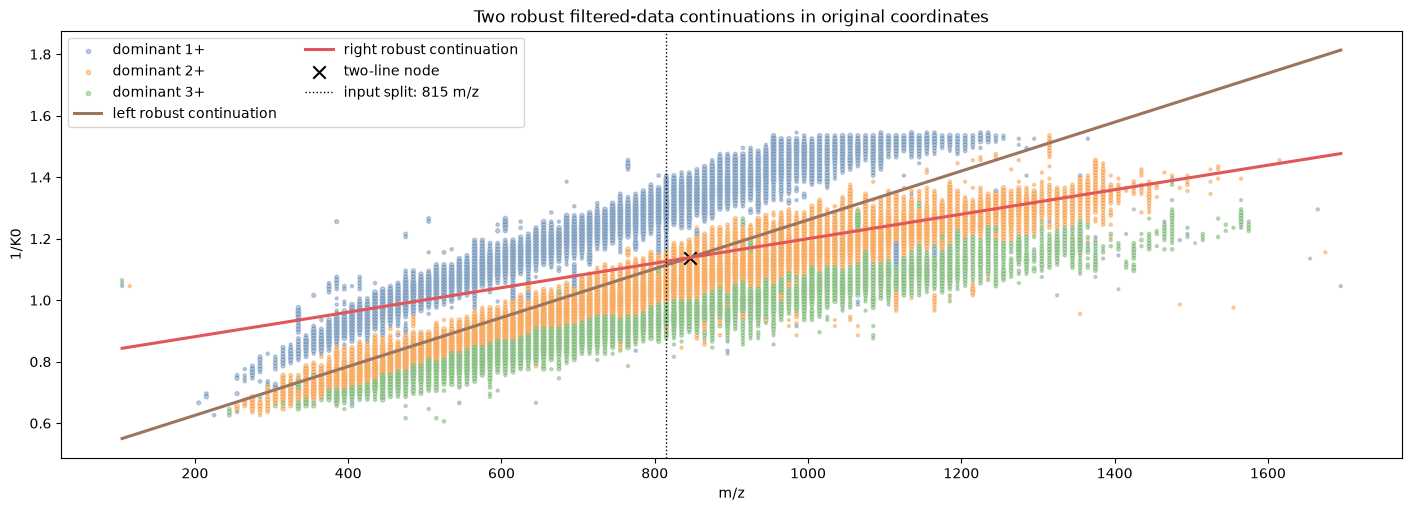

In [16]:
figure, axis = plt.subplots(figsize=(14, 5), constrained_layout=True)
colours = {1: '#4c78a8', 2: '#f58518', 3: '#54a24b'}
for charge, colour in colours.items():
    points = dominant_charges.loc[dominant_charges.dominant_charge == charge]
    axis.scatter(
        points.mz, points.inv_ion_mobility,
        s=np.clip(np.log1p(points.intensity_weight), 2, 18),
        color=colour, alpha=0.35, label=f'dominant {charge}+',
    )
mz_line = np.array([dominant_charges.mz.min(), dominant_charges.mz.max()])
axis.plot(mz_line, left_line[0] + left_line[1] * mz_line, color='#9c755f', linewidth=2.2, label='left robust continuation')
axis.plot(mz_line, right_line[0] + right_line[1] * mz_line, color='#e15759', linewidth=2.2, label='right robust continuation')
axis.scatter(node_mz, node_mobility, color='black', marker='x', s=80, label='two-line node')
axis.axvline(split_mz, color='black', linestyle=':', linewidth=1, label=f'input split: {split_mz:g} m/z')
axis.set(xlabel='m/z', ylabel='1/K0', title='Two robust filtered-data continuations in original coordinates')
axis.legend(ncol=2)
plt.show()
